In [10]:
!pip install scipy

In [18]:
!pip install tableone

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 38.0 MB/s  0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [tableone]1/3 [statsmodels]


## 確認樣本數量與欄位數量


In [1]:
import pandas as pd

In [3]:
df = pd.read_excel(
    r"/Users/claireweng/Desktop/碩士論文整理/模型二/RTOC_provide20260208.xlsx")

df 

,ID,Institute,Group,Muscle_loss,Sex,Age,ECOG,Tumor_site,Stage,Chemotherapy,...,EIM,GL,IPCM,MPCM,SPCM,SGL,Post_SMI,SMI_change,CT_duration,RT_duration
0,1,0,2,0,2,49,1,3,1,0,...,35.822,42.211,43.055,49.155,51.844,48.356,47.748315,4.432517,99,45
1,3,0,2,0,2,29,0,1,1,0,...,46.600,40.700,36.700,40.300,41.600,42.000,63.821972,-3.642552,102,52
2,4,0,2,0,2,55,0,3,1,1,...,39.300,39.800,42.900,45.100,41.500,45.800,62.044468,11.560003,94,48
3,5,0,2,0,2,63,0,2,1,1,...,35.608,42.017,41.887,47.827,49.638,44.922,66.327515,-0.152362,112,46
4,6,0,2,0,2,68,1,3,1,0,...,40.600,45.800,39.600,45.400,52.300,46.000,62.319118,-1.298002,97,48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1019,100773,1,1,0,2,50,0,3,0,0,...,36.711,39.164,40.355,41.244,46.114,41.508,56.457093,-0.867555,93,44
1020,100774,1,1,1,2,55,1,2,1,0,...,44.823,48.035,50.355,63.034,62.721,51.366,42.622768,-4.642607,99,43
1021,100775,1,0,0,1,72,0,1,1,0,...,38.133,40.783,41.004,43.745,45.706,43.514,51.045448,2.265108,102,44
1022,100776,1,0,0,2,46,1,1,1,0,...,45.566,48.134,50.155,58.433,63.175,51.388,48.560079,-5.269333,100,47


In [6]:
print("資料形狀：", df.shape)
print(f"樣本數（rows）：{df.shape[0]}")
print(f"醫院/結果/特徵數（columns）：{df.shape[1]}")

資料形狀： (1024, 26)
樣本數（rows）：1024
醫院/結果/特徵數（columns）：26


## 確認欄位哪些是連續（分布）哪些是類別（什麼類別、幾筆）

In [7]:
print("特徵名稱：")
print(df.columns.tolist())

特徵名稱：
['ID', 'Institute', 'Group', 'Muscle_loss', 'Sex', 'Age', 'ECOG', 'Tumor_site', 'Stage', 'Chemotherapy', 'NLR', 'Pre_SMI', 'CCI', 'MNA', 'CE', 'CPA', 'EIM', 'GL', 'IPCM', 'MPCM', 'SPCM', 'SGL', 'Post_SMI', 'SMI_change', 'CT_duration', 'RT_duration']


In [8]:
data_types = df.dtypes

# 排除 'Institute' 和 'Group'
features_to_check = [col for col in df.columns if col not in ['Institute', 'Group']]

# 篩選並印出這些特徵的資料類型
print(data_types.loc[features_to_check])

ID                int64
Muscle_loss       int64
Sex               int64
Age               int64
ECOG              int64
Tumor_site        int64
Stage             int64
Chemotherapy      int64
NLR             float64
Pre_SMI         float64
CCI               int64
MNA               int64
CE              float64
CPA             float64
EIM             float64
GL              float64
IPCM            float64
MPCM            float64
SPCM            float64
SGL             float64
Post_SMI        float64
SMI_change      float64
CT_duration       int64
RT_duration       int64
dtype: object


In [9]:
# 計算每個特徵的缺失值數量
missing_values_count = df.isnull().sum()

# 印出結果
print("--- 特徵缺失值數量 ---")
print(missing_values_count)


--- 特徵缺失值數量 ---
ID              0
Institute       0
Group           0
Muscle_loss     0
Sex             0
Age             0
ECOG            0
Tumor_site      0
Stage           0
Chemotherapy    0
NLR             0
Pre_SMI         0
CCI             0
MNA             0
CE              0
CPA             0
EIM             0
GL              0
IPCM            0
MPCM            0
SPCM            0
SGL             0
Post_SMI        0
SMI_change      0
CT_duration     0
RT_duration     0
dtype: int64


In [10]:
categorical_features = ['Sex', 'ECOG', 'Tumor_site', 'Stage', 'Chemotherapy','Muscle_loss']

print("\n--- 類別特徵的分佈 ---")
for feature in categorical_features:
    print(f"\n特徵: {feature}")
    # 輸出每個類別的計數
    print(df[feature].value_counts())


--- 類別特徵的分佈 ---

特徵: Sex
Sex
2    885
1    139
Name: count, dtype: int64

特徵: ECOG
ECOG
0    710
1    314
Name: count, dtype: int64

特徵: Tumor_site
Tumor_site
2    373
1    366
3    285
Name: count, dtype: int64

特徵: Stage
Stage
1    852
0    172
Name: count, dtype: int64

特徵: Chemotherapy
Chemotherapy
1    630
0    394
Name: count, dtype: int64

特徵: Muscle_loss
Muscle_loss
0    760
1    264
Name: count, dtype: int64



--- Categorical Feature Distribution Bar Charts (R2Omics Colors, Sorted, Horizontal X-Labels) ---


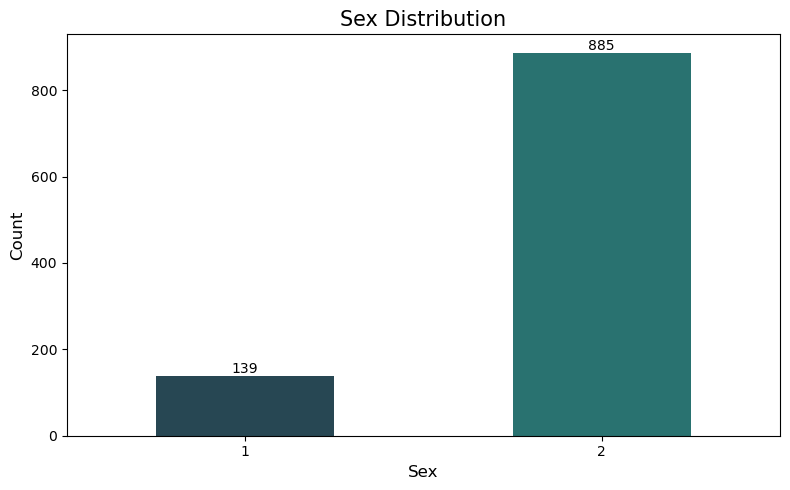

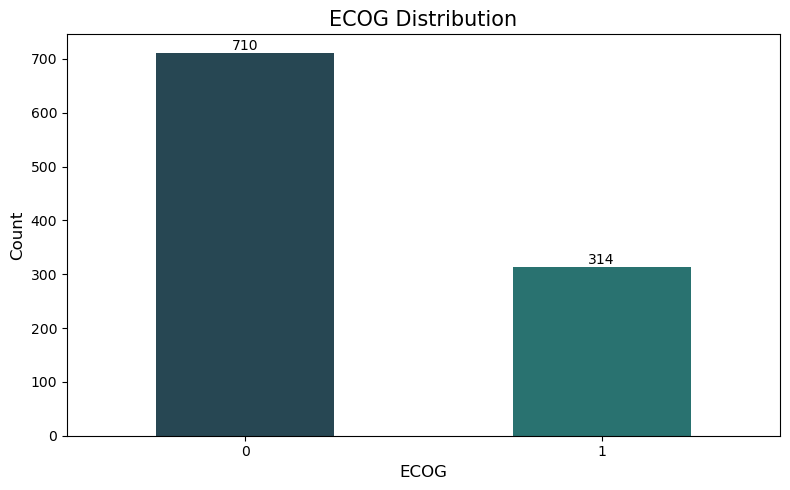

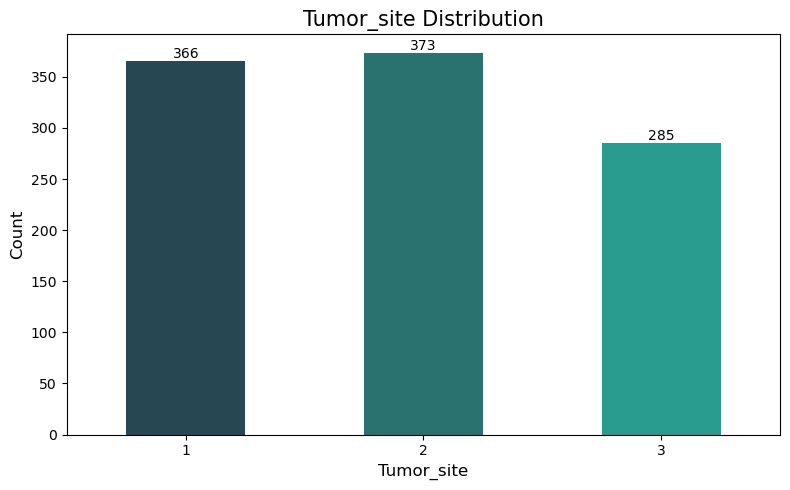

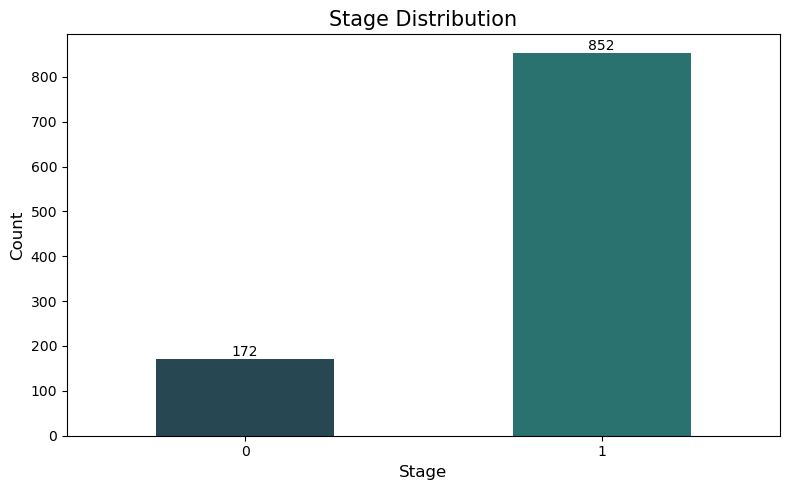

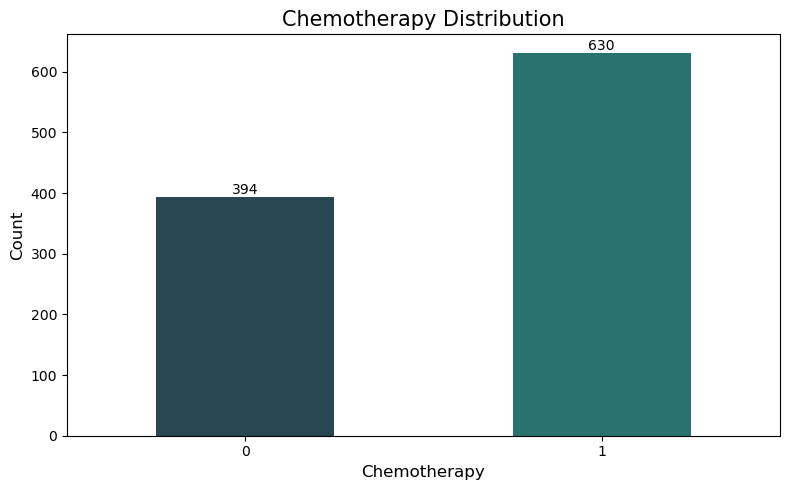

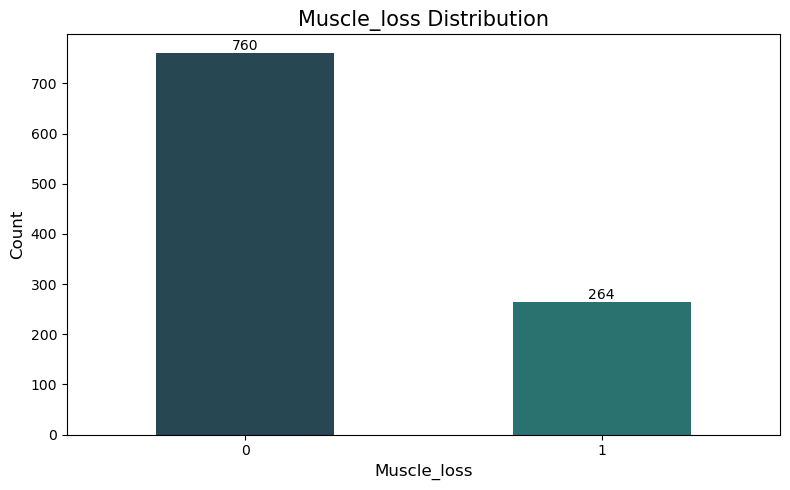

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

r2omics_colors = ['#274753', '#297270', '#299c8f', '#8ab07c', '#e7c66b', '#f3a361', '#e66d50']

categorical_features = ['Sex', 'ECOG', 'Tumor_site', 'Stage', 'Chemotherapy','Muscle_loss']

print("\n--- Categorical Feature Distribution Bar Charts (R2Omics Colors, Sorted, Horizontal X-Labels) ---")
for feature in categorical_features:
    value_counts = df[feature].value_counts(dropna=False)
    
    # 依類別數值排序 
    try:
        sorted_counts = value_counts.sort_index(key=lambda x: x.astype(int))
    except ValueError:
        sorted_counts = value_counts.sort_index()

    plt.figure(figsize=(8, 5))
    
    sorted_counts.plot(kind='bar', color=r2omics_colors[:len(sorted_counts)]) 
    
    # 設定標題和軸標籤
    plt.title(f'{feature} Distribution', fontsize=15)
    plt.xlabel(f'{feature}', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    
    # 強制 X 軸標籤水平顯示
    plt.xticks(rotation=0, ha='center')
    
    # 在每個長條上方顯示數值
    for index, value in enumerate(sorted_counts):
        plt.text(index, value, str(value), ha='center', va='bottom')
    # 移除格線
    # plt.grid(axis='y', linestyle='--', alpha=0.7) # 之前已移除此行
    plt.tight_layout()
    plt.show()

In [12]:
# 排除 'ID', 'Institute', 'Group' 以及已檢查的類別特徵
all_features = df.columns.tolist()
excluded_features = ['ID', 'Institute', 'Group'] + categorical_features
continuous_features = [f for f in all_features if f not in excluded_features]
continuous_describe = df[continuous_features].describe()
print("\n--- 連續特徵的描述性統計分佈 ---")
# 顯示所有連續特徵的統計量
continuous_describe


--- 連續特徵的描述性統計分佈 ---


,Age,NLR,Pre_SMI,CCI,MNA,CE,CPA,EIM,GL,IPCM,MPCM,SPCM,SGL,Post_SMI,SMI_change,CT_duration,RT_duration
count,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000
mean,55.089844,3.405309,51.291154,1.388672,24.704102,34.614529,39.489872,37.216786,41.621613,43.447967,48.138981,51.259540,45.210599,50.379981,-1.818605,101.226562,46.624023
std,10.288779,2.270109,8.461394,1.204954,2.853775,7.512794,6.137858,6.638797,5.783684,4.650771,4.407500,5.063805,5.144326,8.630980,3.755589,8.753574,3.402352
min,29.000000,0.596154,26.008191,0.000000,15.000000,0.800000,1.400000,1.000000,1.500000,16.200000,32.900000,32.800000,24.000000,25.547595,-19.165311,71.000000,33.000000
25%,48.000000,2.034195,45.379589,0.000000,23.000000,31.475000,36.100000,33.633000,39.324750,41.000000,45.300000,47.954500,42.300000,44.443994,-4.256353,95.000000,44.000000
50%,55.000000,2.818182,50.408169,1.000000,25.000000,35.100000,40.307500,37.684000,42.507000,43.605500,48.078500,51.156500,45.600000,49.538184,-2.111042,100.000000,46.000000
75%,62.000000,4.000000,56.035507,2.000000,27.000000,39.200000,43.379250,41.228750,45.000000,46.385000,50.700000,53.900000,48.100000,55.205128,0.776955,106.000000,48.000000
max,89.000000,21.500000,85.297092,6.000000,29.000000,61.200000,58.800000,56.200000,60.900000,58.900000,64.900000,66.100000,68.000000,83.339985,11.560003,131.000000,63.000000


連續型特徵數量：18
子圖排列：6 列 × 3 欄


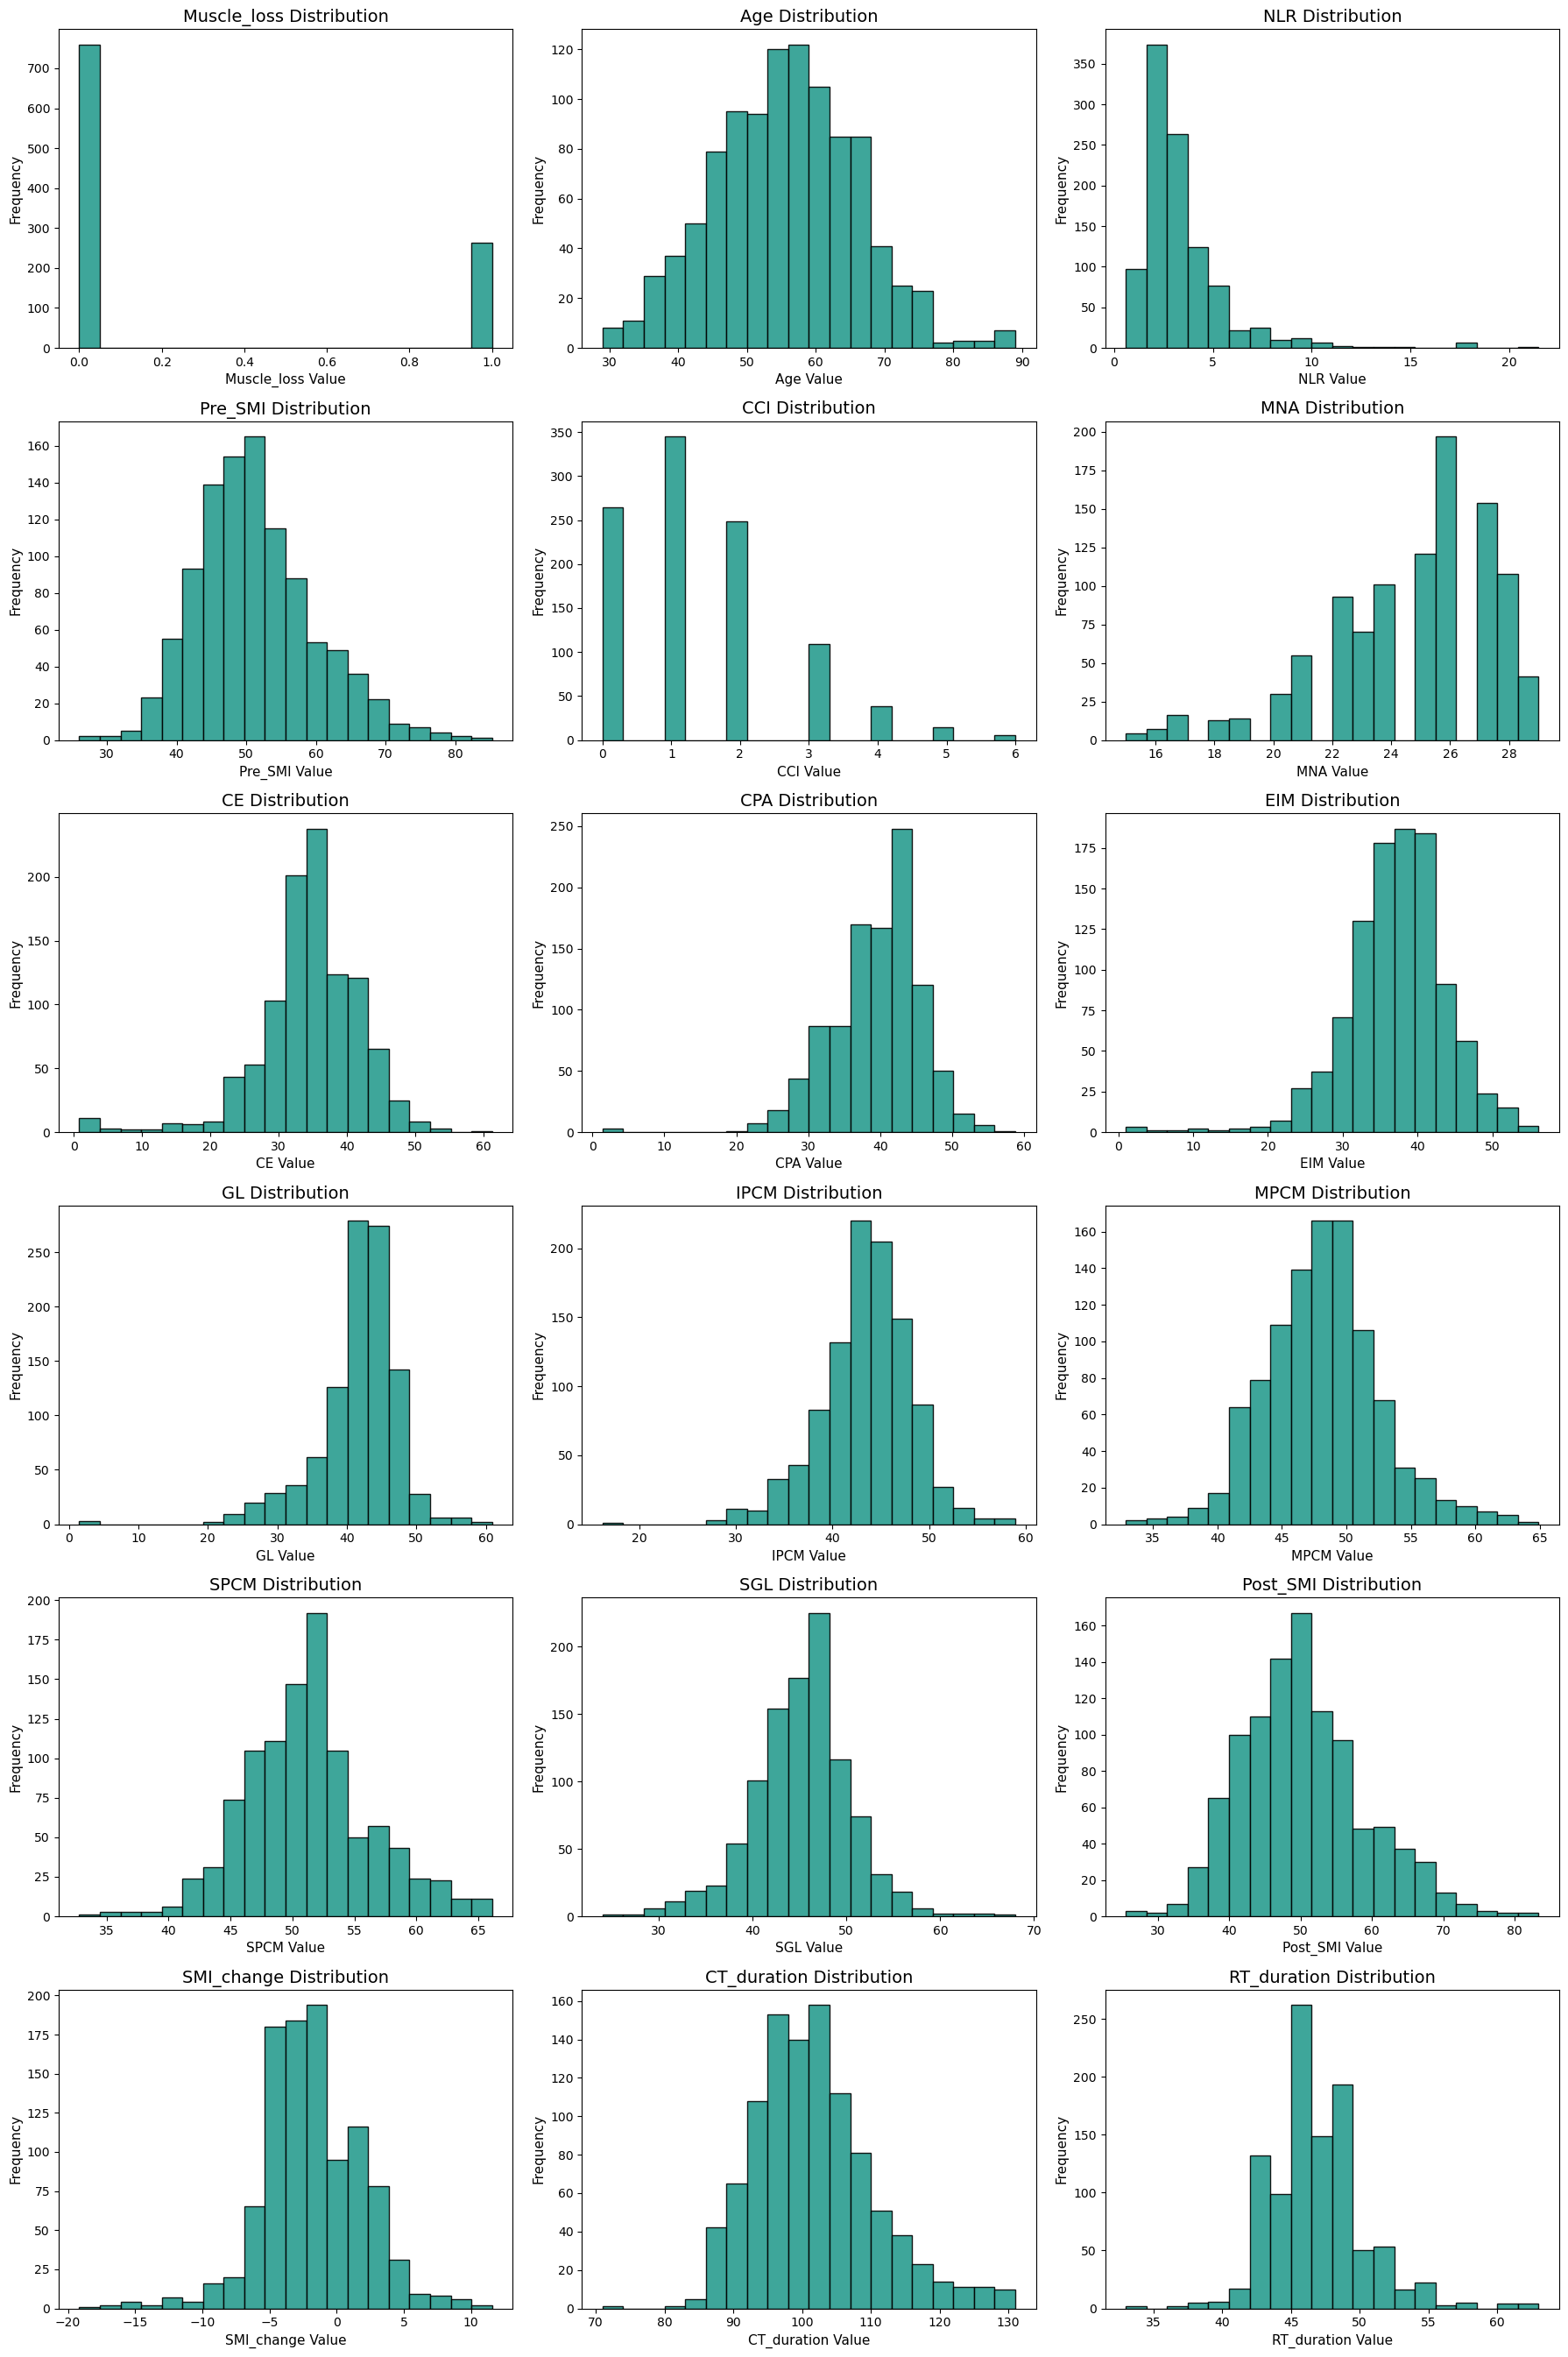

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# 使用 R2Omics 配色作為直方圖填充色
histogram_color = "#299c8f"

# 排除識別、分組與類別型欄位
categorical_features = ["Sex", "ECOG", "Tumor_site", "Stage", "Chemotherapy"]
excluded_features = ["ID", "Institute", "Group"] + categorical_features

# 篩選要呈現分布的連續型特徵
continuous_features = [col for col in df.columns if col not in excluded_features]

# 根據特徵數量自動設定子圖排列
num_features = len(continuous_features)
n_cols = 3
n_rows = (num_features + n_cols - 1) // n_cols

print(f"連續型特徵數量：{num_features}")
print(f"子圖排列：{n_rows} 列 × {n_cols} 欄")

# 建立子圖並繪製各連續型特徵的直方圖
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4.5))
axes = axes.flatten()

for i, feature in enumerate(continuous_features):
    ax = axes[i]
    df[feature].hist(ax=ax, bins=20, edgecolor="black", color=histogram_color, alpha=0.9)
    ax.set_title(f"{feature} Distribution", fontsize=14)
    ax.set_xlabel(f"{feature} Value", fontsize=11)
    ax.set_ylabel("Frequency", fontsize=11)
    ax.grid(False)

# 移除未使用的子圖
for i in range(num_features, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

## CCH MMH樣本數量確認

In [15]:
# 取得每個 'Institute' 的人數計數
institute_counts = df['Institute'].value_counts(dropna=False)

# 定義編碼映射
institute_map = {0: 'MMH（0）', 1: 'CCH（1）'}

# 將索引（0, 1）換為（MMH, CCH）
mapped_counts = institute_counts.rename(institute_map)

print("\n--- 'Institute' 人數分佈 (MMH/CCH) ---")
print(mapped_counts)


--- 'Institute' 人數分佈 (MMH/CCH) ---
Institute
CCH（1）    636
MMH（0）    388
Name: count, dtype: int64


In [16]:
import pandas as pd

# 定義編碼映射
institute_map = {0: 'MMH', 1: 'CCH'}
df_temp = df.copy()
df_temp['Institute_Name'] = df_temp['Institute'].replace(institute_map)

# 1. 計算人數 
loss_counts = pd.crosstab(df_temp['Institute_Name'], df_temp['Muscle_loss'], dropna=False)

# 2. 計算佔比 
loss_proportions = pd.crosstab(df_temp['Institute_Name'], df_temp['Muscle_loss'], 
                               dropna=False, normalize='index') * 100

print("\n--- 'Institute' 對 'Muscle_loss' 的人數分佈 ---")
print(loss_counts)

print("\n--- 'Institute' 對 'Muscle_loss' 的佔比 (%) ---")
# 保留兩位小數
print(loss_proportions.round(2))


--- 'Institute' 對 'Muscle_loss' 的人數分佈 ---
Muscle_loss       0    1
Institute_Name          
CCH             470  166
MMH             290   98

--- 'Institute' 對 'Muscle_loss' 的佔比 (%) ---
Muscle_loss         0      1
Institute_Name              
CCH             73.90  26.10
MMH             74.74  25.26


# 匯入資料，先確認描述性分析特徵與要排除特徵

In [17]:
import pandas as pd
# 讀取 Train70 工作表
train_set = pd.read_excel("RTOC_provide20251009_group_only_for_me.xlsx", sheet_name='Train')

# 讀取 InternalTest30 工作表
internal_test_set = pd.read_excel("RTOC_provide20251009_group_only_for_me.xlsx", sheet_name='InternalTest')

train_set #445

,ID,Institute,Group,Muscle_loss,Sex,Age,ECOG,Tumor_site,Stage,Chemotherapy,...,CCI,MNA,CE,CPA,EIM,GL,IPCM,MPCM,SPCM,SGL
0,99991,1,0,0,2,47,0,1,1,1,...,1,26,35.500,42.300,40.200,41.500,44.900,45.200,47.800,40.000
1,99993,1,0,0,2,30,0,1,1,0,...,0,25,35.700,28.600,25.700,30.700,34.700,49.200,53.400,40.100
2,99994,1,0,0,2,54,0,3,1,1,...,1,27,22.500,40.600,36.700,33.600,39.200,43.500,42.900,40.400
3,99997,1,0,0,2,58,1,1,1,1,...,1,25,36.700,42.500,40.500,43.800,45.700,48.900,54.200,44.200
4,99998,1,0,0,2,38,0,2,1,0,...,0,29,29.000,43.500,43.100,43.900,44.100,46.700,48.000,45.700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440,100770,1,0,0,1,67,0,3,1,0,...,2,24,25.100,28.803,30.204,37.165,36.914,42.213,43.874,40.702
441,100771,1,0,0,2,45,0,2,1,1,...,0,24,28.100,38.942,39.398,41.152,43.655,44.679,47.133,43.891
442,100775,1,0,0,1,72,0,1,1,0,...,4,29,34.000,37.504,38.133,40.783,41.004,43.745,45.706,43.514
443,100776,1,0,0,2,46,1,1,1,0,...,2,27,33.104,46.874,45.566,48.134,50.155,58.433,63.175,51.388


In [18]:
internal_test_set #191

,ID,Institute,Group,Muscle_loss,Sex,Age,ECOG,Tumor_site,Stage,Chemotherapy,...,CCI,MNA,CE,CPA,EIM,GL,IPCM,MPCM,SPCM,SGL
0,99992,1,1,0,2,39,0,2,1,1,...,0,28,19.100,39.000,51.600,44.200,42.600,44.500,45.100,35.100
1,99995,1,1,0,2,62,1,2,1,1,...,2,24,28.800,41.800,41.300,45.700,46.800,50.500,52.100,46.900
2,100001,1,1,0,2,53,0,2,1,0,...,1,25,35.018,41.083,38.956,40.576,44.128,47.802,50.217,46.714
3,100004,1,1,1,2,41,0,1,1,1,...,0,22,42.200,36.600,37.700,41.200,42.400,45.400,58.900,45.800
4,100008,1,1,0,2,58,0,2,0,0,...,1,28,24.000,42.600,40.100,42.800,40.600,45.900,48.600,45.100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186,100744,1,1,0,2,43,0,2,1,1,...,0,27,32.607,35.576,36.301,37.300,37.600,41.882,45.563,41.387
187,100772,1,1,1,2,82,1,3,1,1,...,6,22,34.423,46.697,43.898,48.794,50.304,58.311,60.384,51.721
188,100773,1,1,0,2,50,0,3,0,0,...,0,27,35.345,36.634,36.711,39.164,40.355,41.244,46.114,41.508
189,100774,1,1,1,2,55,1,2,1,0,...,3,21,33.815,47.356,44.823,48.035,50.355,63.034,62.721,51.366


In [19]:
# 讀取 ExternalTest 工作表
External_set = pd.read_excel("RTOC_provide20251009_group_only_for_me.xlsx", sheet_name='ExternalTest')

External_set # 388

,ID,Institute,Group,Muscle_loss,Sex,Age,ECOG,Tumor_site,Stage,Chemotherapy,...,CCI,MNA,CE,CPA,EIM,GL,IPCM,MPCM,SPCM,SGL
0,1,0,2,0,2,49,1,3,1,0,...,0,26,32.704,44.366,35.822,42.211,43.055,49.155,51.844,48.356
1,3,0,2,0,2,29,0,1,1,0,...,0,27,43.200,43.900,46.600,40.700,36.700,40.300,41.600,42.000
2,4,0,2,0,2,55,0,3,1,1,...,1,27,25.600,43.600,39.300,39.800,42.900,45.100,41.500,45.800
3,5,0,2,0,2,63,0,2,1,1,...,2,24,33.811,41.657,35.608,42.017,41.887,47.827,49.638,44.922
4,6,0,2,0,2,68,1,3,1,0,...,2,25,41.700,48.500,40.600,45.800,39.600,45.400,52.300,46.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
383,682,0,2,0,1,70,1,3,1,0,...,3,28,30.374,40.158,39.804,38.734,41.625,45.381,44.943,40.387
384,683,0,2,0,2,42,0,1,1,0,...,0,27,36.700,38.203,40.122,38.855,39.400,40.308,46.374,43.671
385,684,0,2,0,2,46,1,3,1,1,...,2,26,31.614,35.633,37.924,43.044,43.853,57.500,44.328,42.877
386,685,0,2,0,2,51,1,3,1,1,...,1,28,35.577,41.685,38.255,43.313,42.785,44.258,45.809,43.735


In [20]:
column_names_list = list(train_set.columns)
print(column_names_list)

['ID', 'Institute', 'Group', 'Muscle_loss', 'Sex', 'Age', 'ECOG', 'Tumor_site', 'Stage', 'Chemotherapy', 'NLR', 'Pre_SMI', 'CCI', 'MNA', 'CE', 'CPA', 'EIM', 'GL', 'IPCM', 'MPCM', 'SPCM', 'SGL']


In [22]:
# 不納入分析: ID
# 分組依據： Institute or Group
# 連續型: 'Age', 'NLR', 'Pre_SMI', 'CCI', 'MNA', 'CE', 'CPA', 'EIM', 'GL', 'IPCM', 'MPCM', 'SPCM', 'SGL'
# 類別型: Muscle_loss, Sex, ECOG, Tumor_site, Stage, Chemotherapy, 

# 描述性分析（依據Institute分）

In [25]:
# 合併train_set internal_test_set External_set
train_set_copy = train_set.copy()
internal_test_set_copy = internal_test_set.copy()
External_set_copy = External_set.copy()


# 用 pd.concat()
all_data = pd.concat(
    [train_set_copy, internal_test_set_copy, External_set_copy],
    ignore_index=True
)

In [26]:
import scipy.stats as stats
import numpy as np

# 模型二的連續型變項
continuous_vars = [
    "Age", "NLR", "Pre_SMI", "CCI", "MNA", "CE", "CPA",
    "EIM", "GL", "IPCM", "MPCM", "SPCM", "SGL"
]

# 小樣本使用 Shapiro-Wilk；大樣本同時參考偏態與峰度
LARGE_SAMPLE_CUTOFF = 50
ALPHA = 0.05
SKEW_LIMIT = 2.0
KURT_LIMIT = 3.0

def check_normality(data, group_name):
    """依樣本數、Shapiro-Wilk、偏態與峰度判斷是否可視為常態。"""
    n = len(data)
    _, p_value = stats.shapiro(data)
    skewness = stats.skew(data)
    kurtosis = stats.kurtosis(data)  # Fisher's kurtosis，常態分布為 0

    print(
        f"  {group_name} (n={n}): Shapiro p={p_value:.4f} | "
        f"Skew={skewness:.2f}, Kurt={kurtosis:.2f}"
    )

    # 小樣本依 Shapiro-Wilk p 值判斷
    if n < LARGE_SAMPLE_CUTOFF:
        is_normal = p_value > ALPHA
        reason = f"p > {ALPHA}" if is_normal else f"p ≤ {ALPHA}"

    # 大樣本考量 Shapiro-Wilk 對微小偏離較敏感，
    # Shapiro 通過或偏態與峰度在設定範圍內，皆視為近似常態
    else:
        distribution_shape_ok = (
            abs(skewness) < SKEW_LIMIT
            and abs(kurtosis) < KURT_LIMIT
        )
        is_normal = (p_value > ALPHA) or distribution_shape_ok
        reason = (
            "Shapiro pass" if p_value > ALPHA
            else "Skew/Kurt acceptable" if distribution_shape_ok
            else "Skew/Kurt outside limits"
        )

    return is_normal, reason

nonnormal_recommendation_list = []

print(
    f"常態性評估：n < {LARGE_SAMPLE_CUTOFF} 使用 Shapiro-Wilk；"
    "較大樣本同時參考偏態與峰度"
)

for col in continuous_vars:
    if col not in all_data.columns:
        print(f"\n{col}: 欄位不存在，已跳過。")
        continue

    print(f"\n--- 變項：{col} ---")

    # 取得兩個醫院的有效觀測值
    mmh_data = all_data.loc[all_data["Institute"] == 0, col].dropna()
    cch_data = all_data.loc[all_data["Institute"] == 1, col].dropna()

    # Shapiro-Wilk 至少需要 3 筆資料
    if len(mmh_data) < 3 or len(cch_data) < 3:
        print(
            f"  樣本數不足，已跳過："
            f"MMH n={len(mmh_data)}, CCH n={len(cch_data)}"
        )
        continue

    mmh_normal, mmh_reason = check_normality(mmh_data, "MMH (0)")
    cch_normal, cch_reason = check_normality(cch_data, "CCH (1)")

    if mmh_normal and cch_normal:
        # 兩組均視為常態時，以 Levene's test 判斷變異數同質性
        _, levene_p = stats.levene(mmh_data, cch_data)
        equal_variance = levene_p > ALPHA
        recommended_test = (
            "Student's t-test"
            if equal_variance
            else "Welch's t-test"
        )

        print(f"  結論：視為常態（{mmh_reason}, {cch_reason}）")
        print(
            f"  Levene's test：p={levene_p:.3f}，"
            f"{'變異數相等' if equal_variance else '變異數不相等'}"
        )
        print(f"  建議：{recommended_test}；呈現 Mean (SD)")

    else:
        # 任一組不符合常態時採用非參數檢定
        nonnormal_recommendation_list.append(col)
        print(f"  結論：視為非常態（{mmh_reason}, {cch_reason}）")
        print("  建議：Mann-Whitney U test；呈現 Median [IQR]")

print("\n" + "=" * 60)
print("TableOne 建議設定：")
print(f"nonnormal_vars = {nonnormal_recommendation_list}")
print("=" * 60)

常態性評估：n < 50 使用 Shapiro-Wilk；較大樣本同時參考偏態與峰度

--- 變項：Age ---
  MMH (0) (n=388): Shapiro p=0.0871 | Skew=0.12, Kurt=0.07
  CCH (1) (n=636): Shapiro p=0.0748 | Skew=0.09, Kurt=-0.05
  結論：視為常態（Shapiro pass, Shapiro pass）
  Levene's test：p=0.380，變異數相等
  建議：Student's t-test；呈現 Mean (SD)

--- 變項：NLR ---
  MMH (0) (n=388): Shapiro p=0.0000 | Skew=2.82, Kurt=13.48
  CCH (1) (n=636): Shapiro p=0.0000 | Skew=3.32, Kurt=15.69
  結論：視為非常態（Skew/Kurt outside limits, Skew/Kurt outside limits）
  建議：Mann-Whitney U test；呈現 Median [IQR]

--- 變項：Pre_SMI ---
  MMH (0) (n=388): Shapiro p=0.0000 | Skew=0.53, Kurt=0.08
  CCH (1) (n=636): Shapiro p=0.0000 | Skew=0.62, Kurt=0.85
  結論：視為常態（Skew/Kurt acceptable, Skew/Kurt acceptable）
  Levene's test：p=0.086，變異數相等
  建議：Student's t-test；呈現 Mean (SD)

--- 變項：CCI ---
  MMH (0) (n=388): Shapiro p=0.0000 | Skew=0.90, Kurt=0.65
  CCH (1) (n=636): Shapiro p=0.0000 | Skew=0.89, Kurt=0.82
  結論：視為常態（Skew/Kurt acceptable, Skew/Kurt acceptable）
  Levene's test：p=0.093，變異數相等
  建議

In [27]:
# 確認類別變相哪些用卡方還是費雪
import numpy as np
import pandas as pd
from scipy import stats

# 模型二的類別型變項與分組欄位
categorical_vars = [
    'Muscle_loss', 'Sex', 'ECOG', 'Tumor_site', 'Stage', 'Chemotherapy'
]
grouping_variable = "Institute"

# Cochran's 20% rule 判斷標準
EXPECTED_COUNT_THRESHOLD = 5.0
PERCENTAGE_THRESHOLD = 0.20

chi_square_vars = []
fisher_vars = []

print("類別型變項期望次數評估（Cochran's 20% Rule）")

for col in categorical_vars:
    if col not in all_data.columns:
        print(f"\n{col}: 欄位不存在，已跳過。")
        continue

    print(f"\n--- 變項：{col} ---")

    # 建立醫院來源與類別型變項的列聯表
    contingency_table = pd.crosstab(
        all_data[grouping_variable],
        all_data[col],
    )

    print("觀察次數：")
    print(contingency_table)

    # 列聯表至少需要兩個群體與兩個類別
    if (
        contingency_table.shape[0] < 2
        or contingency_table.shape[1] < 2
    ):
        print("列聯表維度不足，無法進行檢定。")
        continue

    try:
        # 透過卡方檢定取得各儲存格的期望次數
        _, _, _, expected_counts = stats.chi2_contingency(
            contingency_table
        )

        expected_table = pd.DataFrame(
            expected_counts,
            index=contingency_table.index,
            columns=contingency_table.columns,
        ).round(2)

        print("\n期望次數：")
        print(expected_table)

        # 計算期望次數小於 5 的儲存格比例
        total_cells = expected_counts.size
        cells_below_5 = np.sum(
            expected_counts < EXPECTED_COUNT_THRESHOLD
        )
        proportion_below_5 = cells_below_5 / total_cells

        print(
            f"\n期望次數 < 5：{cells_below_5}/{total_cells} "
            f"（{proportion_below_5:.1%}）"
        )

        # 超過 20% 的儲存格期望次數小於 5時，
        # 建議使用 Fisher's exact test
        if proportion_below_5 > PERCENTAGE_THRESHOLD:
            fisher_vars.append(col)
            print("建議：Fisher's exact test。")

        else:
            chi_square_vars.append(col)
            print("建議：Chi-square test。")

            # 此警告維持原程式邏輯，不改變上方檢定建議
            if np.any(expected_counts < 1):
                print(
                    "警告：至少一個儲存格的期望次數小於 1，"
                    "應考慮使用 Fisher's exact test。"
                )

    except ValueError as error:
        fisher_vars.append(col)
        print(f"卡方期望次數計算失敗：{error}")
        print("建議：Fisher's exact test。")

print("\n" + "=" * 60)
print(f"建議使用 Chi-square test：{chi_square_vars}")
print(f"建議使用 Fisher's exact test：{fisher_vars}")
print("=" * 60)

類別型變項期望次數評估（Cochran's 20% Rule）

--- 變項：Muscle_loss ---
觀察次數：
Muscle_loss    0    1
Institute            
0            290   98
1            470  166

期望次數：
Muscle_loss       0       1
Institute                  
0            287.97  100.03
1            472.03  163.97

期望次數 < 5：0/4 （0.0%）
建議：Chi-square test。

--- 變項：Sex ---
觀察次數：
Sex         1    2
Institute         
0          48  340
1          91  545

期望次數：
Sex            1       2
Institute               
0          52.67  335.33
1          86.33  549.67

期望次數 < 5：0/4 （0.0%）
建議：Chi-square test。

--- 變項：ECOG ---
觀察次數：
ECOG         0    1
Institute          
0          271  117
1          439  197

期望次數：
ECOG            0       1
Institute                
0          269.02  118.98
1          440.98  195.02

期望次數 < 5：0/4 （0.0%）
建議：Chi-square test。

--- 變項：Tumor_site ---
觀察次數：
Tumor_site    1    2    3
Institute                
0           131  143  114
1           235  230  171

期望次數：
Tumor_site       1       2       3
Institute     

In [28]:
from tableone import TableOne

continuous_vars = [
    'Age', 'NLR', 'Pre_SMI', 'CCI', 'MNA', 'CE', 'CPA', 'EIM', 
    'GL', 'IPCM', 'MPCM', 'SPCM', 'SGL'
]
categorical_vars = [
    'Muscle_loss', 'Sex', 'ECOG', 'Tumor_site', 'Stage', 'Chemotherapy'
]

# 建立醫院分組標籤
all_data["Institute_Label"] = all_data["Institute"].map({
    0: "MMH",
    1: "CCH",
})

# Table 1 納入的全部變項
all_table_vars = continuous_vars + categorical_vars

# 非常態連續變項以 Median [IQR] 呈現，
# 並使用 Mann-Whitney U test 進行兩組比較
nonnormal_vars = [
    "NLR",
    "CE",
    "CPA",
    "EIM",
    "GL",
]

# 其餘連續變項以 Mean (SD) 呈現並使用 t-test
normal_vars = [
    col for col in continuous_vars
    if col not in nonnormal_vars
]

print("描述性統計設定")
print(f"Mean (SD)：{normal_vars}")
print(f"Median [IQR]：{nonnormal_vars}")

# 檢查兩個醫院的樣本數
print("\n各醫院樣本數")
print(all_data["Institute_Label"].value_counts())

# 建立 CCH 與 MMH 的描述性統計比較表
table1_institute_comparison = TableOne(
    data=all_data,
    columns=all_table_vars,
    categorical=categorical_vars,
    groupby="Institute_Label",
    nonnormal=nonnormal_vars,
    pval=True,
    missing=True,
    overall=True,
)

table1_institute_comparison

描述性統計設定
Mean (SD)：['Age', 'Pre_SMI', 'CCI', 'MNA', 'IPCM', 'MPCM', 'SPCM', 'SGL']
Median [IQR]：['NLR', 'CE', 'CPA', 'EIM', 'GL']

各醫院樣本數
Institute_Label
CCH    636
MMH    388
Name: count, dtype: int64


Grouped by Institute_Label                                                              
                                         Missing           Overall               CCH               MMH P-Value
n                                                             1024               636               388        
Age, mean (SD)                                 0       55.1 (10.3)       54.8 (10.1)       55.5 (10.6)   0.292
NLR, median [Q1,Q3]                            0     2.8 [2.0,4.0]     2.8 [2.0,3.9]     2.8 [2.1,4.0]   0.763
Pre_SMI, mean (SD)                             0        51.3 (8.5)        51.0 (8.3)        51.7 (8.8)   0.210
CCI, mean (SD)                                 0         1.4 (1.2)         1.3 (1.2)         1.5 (1.3)   0.102
MNA, mean (SD)                                 0        24.7 (2.9)        24.8 (2.7)        24.6 (3.1)   0.430
CE, median [Q1,Q3]                             0  35.1 [31.5,39.2]  35.1 [31.3,38.4]  35.2 [31.6,40.2]   0.116
CPA, median [Q1,Q3]                            0  40.3 [36.1,43.4]  39.8 [35.8,43.1]  41.4 [36.5,44.1]   0.008
EIM, median [Q1,Q3]                            0  37.7 [33.6,41.2]  37.6 [33.9,41.4]  37.7 [33.0,41.0]   0.411
GL, median [Q1,Q3]                             0  42.5 [39.3,45.0]  42.3 [39.7,44.8]  42.9 [39.1,45.6]   0.128
IPCM, mean (SD)                                0        43.4 (4.7)        43.6 (4.2)        43.1 (5.3)   0.106
MPCM, mean (SD)                                0        48.1 (4.4)        48.0 (4.1)        48.4 (4.9)   0.133
SPCM, mean (SD)                                0        51.3 (5.1)        51.0 (4.4)        51.7 (5.9)   0.063
SGL, mean (SD)                                 0        45.2 (5.1)        45.0 (4.8)        45.5 (5.7)   0.134
Muscle_loss, n (%)  0                                   760 (74.2)        470 (73.9)        290 (74.7)   0.822
                    1                                   264 (25.8)        166 (26.1)         98 (25.3)        
Sex, n (%)          1                                   139 (13.6)         91 (14.3)         48 (12.4)   0.433
                    2                                   885 (86.4)        545 (85.7)        340 (87.6)        
ECOG, n (%)         0                                   710 (69.3)        439 (69.0)        271 (69.8)   0.837
                    1                                   314 (30.7)        197 (31.0)        117 (30.2)        
Tumor_site, n (%)   1                                   366 (35.7)        235 (36.9)        131 (33.8)   0.534
                    2                                   373 (36.4)        230 (36.2)        143 (36.9)        
                    3                                   285 (27.8)        171 (26.9)        114 (29.4)        
Stage, n (%)        0                                   172 (16.8)        111 (17.5)         61 (15.7)   0.527
                    1                                   852 (83.2)        525 (82.5)        327 (84.3)        
Chemotherapy, n (%) 0                                   394 (38.5)        243 (38.2)        151 (38.9)   0.873
                    1                                   630 (61.5)        393 (61.8)        237 (61.1)

In [10]:
# 2.8 (可選) 匯出表格到 Excel
table1_institute_comparison.to_excel("descriptive_statistics_new_data_byInstitute.xlsx")
print("\n表格已匯出至 'descriptive_statistics_new_data_byInstitute.xlsx'")


表格已匯出至 'descriptive_statistics_new_data_byInstitute.xlsx'


# 描述性分析（依據Group分）

In [31]:
import pandas as pd
import numpy as np
from scipy import stats

# 模型二的連續型變項
continuous_vars = [
    "Age", "NLR", "Pre_SMI", "CCI", "MNA", "CE", "CPA",
    "EIM", "GL", "IPCM", "MPCM", "SPCM", "SGL"
]

# 常態性判斷標準
ALPHA = 0.05
SKEW_LIMIT = 2.0
KURT_LIMIT = 3.0
LARGE_SAMPLE_N = 30

# Group 編碼與資料集名稱
group_labels = {
    0: "Training",
    1: "Internal Validation",
    2: "External Validation",
}

def check_normality(data, group_name):
    """依樣本數、Shapiro-Wilk、偏態與峰度判斷是否可視為常態。"""
    n = len(data)

    if n < 3:
        return False, f"樣本不足（n={n}）"

    _, p_value = stats.shapiro(data)
    skewness = stats.skew(data)
    kurtosis = stats.kurtosis(data)  # Fisher's excess kurtosis，常態為 0

    print(
        f"  {group_name} (n={n}): Shapiro p={p_value:.4f} | "
        f"Skew={skewness:.2f}, Kurt={kurtosis:.2f}"
    )

    pass_shapiro = p_value > ALPHA
    pass_distribution_shape = (
        abs(skewness) <= SKEW_LIMIT
        and abs(kurtosis) <= KURT_LIMIT
    )

    # 小樣本主要依 Shapiro-Wilk test 判斷
    if n < LARGE_SAMPLE_N:
        is_normal = pass_shapiro
        reason = "Shapiro pass" if is_normal else "Shapiro fail"

    # 大樣本若 Shapiro 通過，或偏態與峰度在容許範圍內，
    # 則視為近似常態
    else:
        is_normal = pass_shapiro or pass_distribution_shape
        reason = (
            "Shapiro pass" if pass_shapiro
            else "Skew/Kurt acceptable" if pass_distribution_shape
            else "Skew/Kurt outside limits"
        )

    return is_normal, reason

anova_vars = []
kruskal_vars = []

print(
    f"常態性評估：n < {LARGE_SAMPLE_N} 使用 Shapiro-Wilk；"
    "較大樣本同時參考偏態與峰度"
)

for col in continuous_vars:
    if col not in all_data.columns:
        print(f"\n{col}: 欄位不存在，已跳過。")
        continue

    print(f"\n--- 變項：{col} ---")

    group_data = {
        group_idx: all_data.loc[
            all_data["Group"] == group_idx,
            col,
        ].dropna()
        for group_idx in group_labels
    }

    normality_results = {
        group_idx: check_normality(
            group_data[group_idx],
            group_name,
        )
        for group_idx, group_name in group_labels.items()
    }

    # 三個資料集皆符合常態條件時，進一步檢查變異數同質性
    if all(result[0] for result in normality_results.values()):
        _, levene_p = stats.levene(
            group_data[0],
            group_data[1],
            group_data[2],
        )

        reasons = ", ".join(
            result[1]
            for result in normality_results.values()
        )

        print(f"  結論：三組均視為常態（{reasons}）")

        if levene_p > ALPHA:
            print(f"  Levene's test：p={levene_p:.3f}，變異數相等")
            print("  建議：One-way ANOVA")
        else:
            print(f"  Levene's test：p={levene_p:.3f}，變異數不相等")
            print("  建議：Welch's ANOVA")

        anova_vars.append(col)

    else:
        print("  結論：至少一組不符合常態條件")
        print("  建議：Kruskal-Wallis test")
        kruskal_vars.append(col)

print("\n" + "=" * 60)
print(f"建議使用 ANOVA：{anova_vars}")
print(f"建議使用 Kruskal-Wallis test：{kruskal_vars}")
print(f"TableOne nonnormal_vars = {kruskal_vars}")
print("=" * 60)

常態性評估：n < 30 使用 Shapiro-Wilk；較大樣本同時參考偏態與峰度

--- 變項：Age ---
  Training (n=445): Shapiro p=0.1370 | Skew=0.02, Kurt=0.01
  Internal Validation (n=191): Shapiro p=0.1629 | Skew=0.27, Kurt=-0.21
  External Validation (n=388): Shapiro p=0.0871 | Skew=0.12, Kurt=0.07
  結論：三組均視為常態（Shapiro pass, Shapiro pass, Shapiro pass）
  Levene's test：p=0.672，變異數相等
  建議：One-way ANOVA

--- 變項：NLR ---
  Training (n=445): Shapiro p=0.0000 | Skew=3.10, Kurt=13.95
  Internal Validation (n=191): Shapiro p=0.0000 | Skew=3.49, Kurt=16.07
  External Validation (n=388): Shapiro p=0.0000 | Skew=2.82, Kurt=13.48
  結論：至少一組不符合常態條件
  建議：Kruskal-Wallis test

--- 變項：Pre_SMI ---
  Training (n=445): Shapiro p=0.0000 | Skew=0.64, Kurt=0.88
  Internal Validation (n=191): Shapiro p=0.0048 | Skew=0.54, Kurt=0.64
  External Validation (n=388): Shapiro p=0.0000 | Skew=0.53, Kurt=0.08
  結論：三組均視為常態（Skew/Kurt acceptable, Skew/Kurt acceptable, Skew/Kurt acceptable）
  Levene's test：p=0.160，變異數相等
  建議：One-way ANOVA

--- 變項：CCI ---
  Tra

In [36]:
import pandas as pd
import numpy as np
import scipy.stats as stats

# (假設 'all_data' DataFrame 已經存在於您的環境中)
# ...

# -----------------------------------------------------------------
# 2. 執行您的需求：檢查類別變數 (Cochran's 20% Rule)
# -----------------------------------------------------------------
categorical_vars = [
    'Muscle_loss', 'Sex', 'ECOG', 'Tumor_site', 'Stage', 'Chemotherapy'
]
# !! 確保您的分組欄位名稱正確 (這裡是 'Group') !!
grouping_variable = 'Group' 

# 您的判斷標準
EXPECTED_COUNT_THRESHOLD = 5.0
PERCENTAGE_THRESHOLD = 0.20  # 20%

print("--- 執行類別變數期望次數檢定 (Cochran's 20% Rule) ---")

for col in categorical_vars:
    if col not in all_data.columns:
        print(f"警告: 欄位 {col} 不在資料中，已跳過。")
        continue

    print(f"\n--- 檢定欄位: {col} ---")
    
    # 1. 建立交叉表格 (Contingency Table)
    #    (這會自動建立一個 3xN 的表格)
    contingency_table = pd.crosstab(all_data[grouping_variable], all_data[col])
    
    print("  觀察到的次數 (Observed):")
    print(contingency_table)
    
    # 2. 檢查表格是否為空或太小
    if contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
        print("  -> 警告: 交叉表格維度不足，跳過檢定。")
        continue

    # 3. 計算 Chi-squared 統計量 和 期望次數
    try:
        chi2, p, dof, expected_freq = stats.chi2_contingency(contingency_table)
        
        print("\n  計算出的期望次數 (Expected):")
        print(pd.DataFrame(expected_freq, 
                           index=contingency_table.index, 
                           columns=contingency_table.columns).round(2))

        # 4. 應用 20% 規則
        total_cells = expected_freq.size
        cells_below_threshold = np.sum(expected_freq < EXPECTED_COUNT_THRESHOLD)
        percentage_below = cells_below_threshold / total_cells
        
        print("\n  [檢定規則檢查]")
        print(f"  總儲存格數 (Total Cells)    : {total_cells}")
        print(f"  期望值 < 5 的儲存格數       : {cells_below_threshold}")
        print(f"  不符標準的儲存格百分比      : {percentage_below:.1%} ({cells_below_threshold}/{total_cells})")

        # 5. 判斷與建議
        if percentage_below > PERCENTAGE_THRESHOLD:
            print(f"\n  -> 結論: 超過 {PERCENTAGE_THRESHOLD:.0%} 的儲存格期望值 < 5。")
            print("  -> 建議: 使用 Fisher's Exact Test。")
        else:
            print(f"\n  -> 結論: <= {PERCENTAGE_THRESHOLD:.0%} 的儲存格期望值 < 5。")
            print("  -> 建議: 使用 Chi-squared Test。")
            
    except ValueError as e:
        print(f"  -> 錯誤: 執行檢定時出錯: {e}")
        print("  -> 建議: 這種情況通常應使用 Fisher's Exact Test。")

--- 執行類別變數期望次數檢定 (Cochran's 20% Rule) ---

--- 檢定欄位: Muscle_loss ---
  觀察到的次數 (Observed):
Muscle_loss    0    1
Group                
0            329  116
1            141   50
2            290   98

  計算出的期望次數 (Expected):
Muscle_loss       0       1
Group                      
0            330.27  114.73
1            141.76   49.24
2            287.97  100.03

  [檢定規則檢查]
  總儲存格數 (Total Cells)    : 6
  期望值 < 5 的儲存格數       : 0
  不符標準的儲存格百分比      : 0.0% (0/6)

  -> 結論: <= 20% 的儲存格期望值 < 5。
  -> 建議: 使用 Chi-squared Test。

--- 檢定欄位: Sex ---
  觀察到的次數 (Observed):
Sex     1    2
Group         
0      68  377
1      23  168
2      48  340

  計算出的期望次數 (Expected):
Sex        1       2
Group               
0      60.41  384.59
1      25.93  165.07
2      52.67  335.33

  [檢定規則檢查]
  總儲存格數 (Total Cells)    : 6
  期望值 < 5 的儲存格數       : 0
  不符標準的儲存格百分比      : 0.0% (0/6)

  -> 結論: <= 20% 的儲存格期望值 < 5。
  -> 建議: 使用 Chi-squared Test。

--- 檢定欄位: ECOG ---
  觀察到的次數 (Observed):
ECOG     0    1
Group          
0

In [32]:
import pandas as pd
import numpy as np
from scipy import stats

# 類別變數與三組資料集的分組欄位
categorical_vars = [
    'Muscle_loss', 'Sex', 'ECOG',
    'Tumor_site', 'Stage', 'Chemotherapy'
]
grouping_variable = 'Group'

# Cochran's rule：期望次數低於 5 的儲存格不可超過 20%
EXPECTED_COUNT_THRESHOLD = 5.0
PERCENTAGE_THRESHOLD = 0.20

print("--- 類別變數檢定方法評估（Cochran's 20% Rule）---")

chi_square_vars = []
fisher_vars = []

for col in categorical_vars:
    if col not in all_data.columns:
        print(f"\n警告：找不到欄位 {col}，已跳過。")
        continue

    print(f"\n--- 變數：{col} ---")

    # 建立「資料集組別 × 特徵類別」列聯表
    contingency_table = pd.crosstab(
        all_data[grouping_variable],
        all_data[col]
    )

    print("觀察次數：")
    print(contingency_table)

    # 至少需要兩個資料集組別及兩個特徵類別
    if contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
        print("結論：列聯表維度不足，無法進行檢定。")
        continue

    try:
        # 計算卡方檢定及各儲存格的期望次數
        chi2, p_value, dof, expected_freq = stats.chi2_contingency(
            contingency_table
        )

        expected_table = pd.DataFrame(
            expected_freq,
            index=contingency_table.index,
            columns=contingency_table.columns
        ).round(2)

        print("\n期望次數：")
        print(expected_table)

        # 計算期望次數低於 5 的儲存格比例
        total_cells = expected_freq.size
        cells_below_threshold = np.sum(
            expected_freq < EXPECTED_COUNT_THRESHOLD
        )
        percentage_below = cells_below_threshold / total_cells

        print("\n檢定條件：")
        print(f"總儲存格數：{total_cells}")
        print(f"期望次數 < 5 的儲存格數：{cells_below_threshold}")
        print(
            f"期望次數 < 5 的比例：{percentage_below:.1%} "
            f"({cells_below_threshold}/{total_cells})"
        )

        # 依 Cochran's 20% rule 建議檢定方法
        if percentage_below > PERCENTAGE_THRESHOLD:
            print("建議：Fisher's exact test")
            fisher_vars.append(col)
        else:
            print("建議：Chi-squared test")
            chi_square_vars.append(col)

    except ValueError as error:
        print(f"檢定執行失敗：{error}")
        print("建議：Fisher's exact test")
        fisher_vars.append(col)

print("\n" + "=" * 60)
print(f"建議使用 Chi-squared test：{chi_square_vars}")
print(f"建議使用 Fisher's exact test：{fisher_vars}")
print("=" * 60)

--- 類別變數檢定方法評估（Cochran's 20% Rule）---

--- 變數：Muscle_loss ---
觀察次數：
Muscle_loss    0    1
Group                
0            329  116
1            141   50
2            290   98

期望次數：
Muscle_loss       0       1
Group                      
0            330.27  114.73
1            141.76   49.24
2            287.97  100.03

檢定條件：
總儲存格數：6
期望次數 < 5 的儲存格數：0
期望次數 < 5 的比例：0.0% (0/6)
建議：Chi-squared test

--- 變數：Sex ---
觀察次數：
Sex     1    2
Group         
0      68  377
1      23  168
2      48  340

期望次數：
Sex        1       2
Group               
0      60.41  384.59
1      25.93  165.07
2      52.67  335.33

檢定條件：
總儲存格數：6
期望次數 < 5 的儲存格數：0
期望次數 < 5 的比例：0.0% (0/6)
建議：Chi-squared test

--- 變數：ECOG ---
觀察次數：
ECOG     0    1
Group          
0      299  146
1      140   51
2      271  117

期望次數：
ECOG        0       1
Group                
0      308.54  136.46
1      132.43   58.57
2      269.02  118.98

檢定條件：
總儲存格數：6
期望次數 < 5 的儲存格數：0
期望次數 < 5 的比例：0.0% (0/6)
建議：Chi-squared test

--- 變數：Tumor_site

In [33]:
import pandas as pd
from tableone import TableOne

# 定義連續與類別變數
continuous_vars = [
    'Age', 'NLR', 'Pre_SMI', 'CCI', 'MNA', 'CE', 'CPA',
    'EIM', 'GL', 'IPCM', 'MPCM', 'SPCM', 'SGL'
]
categorical_vars = [
    'Muscle_loss', 'Sex', 'ECOG',
    'Tumor_site', 'Stage', 'Chemotherapy'
]

# 建立資料集分組標籤
all_data['Group_Label'] = all_data['Group'].map({
    0: 'Training',
    1: 'Internal validation',
    2: 'External validation'
})

# 確保連續變數為數值型態；無法轉換的內容設為缺失值
for col in continuous_vars:
    if col in all_data.columns:
        all_data[col] = pd.to_numeric(all_data[col], errors='coerce')

all_table_vars = continuous_vars + categorical_vars

# 非常態變數以 Median [IQR] 呈現，並使用 Kruskal–Wallis test
# 其餘連續變數以 Mean (SD) 呈現，並使用 one-way ANOVA
nonnormal_vars = ['NLR', 'CE', 'CPA', 'EIM', 'GL']

print("--- 各資料集樣本數 ---")
print(all_data['Group_Label'].value_counts())
print("-" * 30)

# 建立三個資料集的描述性統計比較表
table1_dataset_comparison = TableOne(
    all_data,
    columns=all_table_vars,
    categorical=categorical_vars,
    groupby='Group_Label',
    nonnormal=nonnormal_vars,
    pval=True,
    missing=True,
    overall=True
)

table1_dataset_comparison

--- 各資料集樣本數 ---
Group_Label
Training               445
External validation    388
Internal validation    191
Name: count, dtype: int64
------------------------------


Grouped by Group_Label                                                                                    
                                     Missing           Overall External validation Internal validation          Training P-Value
n                                                         1024                 388                 191               445        
Age, mean (SD)                             0       55.1 (10.3)         55.5 (10.6)         54.6 (10.0)       54.9 (10.2)   0.538
NLR, median [Q1,Q3]                        0     2.8 [2.0,4.0]       2.8 [2.1,4.0]       2.9 [2.3,4.2]     2.8 [2.0,3.8]   0.280
Pre_SMI, mean (SD)                         0        51.3 (8.5)          51.7 (8.8)          50.3 (7.9)        51.3 (8.4)   0.169
CCI, mean (SD)                             0         1.4 (1.2)           1.5 (1.3)           1.3 (1.1)         1.4 (1.2)   0.194
MNA, mean (SD)                             0        24.7 (2.9)          24.6 (3.1)          24.5 (2.6)        24.9 (2.7)   0.150
CE, median [Q1,Q3]                         0  35.1 [31.5,39.2]    35.2 [31.6,40.2]    35.0 [30.8,38.1]  35.1 [31.6,38.8]   0.275
CPA, median [Q1,Q3]                        0  40.3 [36.1,43.4]    41.4 [36.5,44.1]    39.6 [36.5,43.2]  39.8 [35.6,43.1]   0.029
EIM, median [Q1,Q3]                        0  37.7 [33.6,41.2]    37.7 [33.0,41.0]    38.0 [34.5,41.4]  37.3 [33.8,41.4]   0.439
GL, median [Q1,Q3]                         0  42.5 [39.3,45.0]    42.9 [39.1,45.6]    42.6 [40.0,45.1]  42.2 [39.7,44.5]   0.094
IPCM, mean (SD)                            0        43.4 (4.7)          43.1 (5.3)          43.8 (4.4)        43.6 (4.1)   0.197
MPCM, mean (SD)                            0        48.1 (4.4)          48.4 (4.9)          48.2 (4.0)        47.9 (4.1)   0.214
SPCM, mean (SD)                            0        51.3 (5.1)          51.7 (5.9)          51.2 (4.3)        50.9 (4.5)   0.109
SGL, mean (SD)                             0        45.2 (5.1)          45.5 (5.7)          44.9 (4.9)        45.1 (4.7)   0.269
Muscle_loss, n (%)  0                               760 (74.2)          290 (74.7)          141 (73.8)        329 (73.9)   0.956
                    1                               264 (25.8)           98 (25.3)           50 (26.2)        116 (26.1)        
Sex, n (%)          1                               139 (13.6)           48 (12.4)           23 (12.0)         68 (15.3)   0.374
                    2                               885 (86.4)          340 (87.6)          168 (88.0)        377 (84.7)        
ECOG, n (%)         0                               710 (69.3)          271 (69.8)          140 (73.3)        299 (67.2)   0.298
                    1                               314 (30.7)          117 (30.2)           51 (26.7)        146 (32.8)        
Tumor_site, n (%)   1                               366 (35.7)          131 (33.8)           66 (34.6)        169 (38.0)   0.428
                    2                               373 (36.4)          143 (36.9)           78 (40.8)        152 (34.2)        
                    3                               285 (27.8)          114 (29.4)           47 (24.6)        124 (27.9)        
Stage, n (%)        0                               172 (16.8)           61 (15.7)           32 (16.8)         79 (17.8)   0.736
                    1                               852 (83.2)          327 (84.3)          159 (83.2)        366 (82.2)        
Chemotherapy, n (%) 0                               394 (38.5)          151 (38.9)           77 (40.3)        166 (37.3)   0.755
                    1                               630 (61.5)          237 (61.1)          114 (59.7)        279 (62.7)

In [13]:
table1_dataset_comparison.to_excel("descriptive_statistics_new_data_byGroup.xlsx")
print("\n表格已匯出至 'descriptive_statistics_new_data_byGroup.xlsx'")


表格已匯出至 'descriptive_statistics_new_data_byGroup.xlsx'


# 針對 有無肌肉流失個案作比較

In [34]:
import pandas as pd
from scipy import stats

def auto_group_comparison(
    df,
    label_col,
    dataset_name="Data",
    exclude_cols=None,
    categorical_threshold=5
):
    """比較肌肉流失與未流失組之間的特徵差異。"""

    if exclude_cols is None:
        exclude_cols = ['ID', 'Institute', 'Group', 'Split']

    print(f"\n{'=' * 20} {dataset_name}: 正負樣本差異分析 {'=' * 20}")

    # 排除標籤及不納入分析的識別／分組欄位
    excluded = set(exclude_cols + [label_col])
    features = [col for col in df.columns if col not in excluded]

    for col in features:
        nunique = df[col].nunique(dropna=True)
        is_numeric = pd.api.types.is_numeric_dtype(df[col])

        # 非數值型或唯一值不超過門檻者視為類別變數
        if not is_numeric or nunique <= categorical_threshold:
            contingency_table = pd.crosstab(df[col], df[label_col])

            if contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
                print(f"欄位: {col:15} | 無法檢定：類別數不足")
                continue

            _, p, _, _ = stats.chi2_contingency(contingency_table)
            method = "Chi-square"
            report = "n (%)"

        else:
            # 分別檢查正、負樣本組的常態性
            groups = sorted(df[label_col].dropna().unique())

            if len(groups) != 2:
                print(f"欄位: {col:15} | 無法檢定：標籤不是兩組")
                continue

            group_data = [
                df.loc[df[label_col] == group, col].dropna()
                for group in groups
            ]

            # 任一組 Shapiro–Wilk p < 0.05，即視為非常態
            is_normal = all(
                len(data) >= 3 and stats.shapiro(data).pvalue >= 0.05
                for data in group_data
            )

            if is_normal:
                _, p = stats.ttest_ind(group_data[0], group_data[1])
                method = "T-test"
                report = "Mean (SD)"
            else:
                _, p = stats.mannwhitneyu(group_data[0], group_data[1])
                method = "Mann-Whitney U"
                report = "Median (IQR)"

        sig_star = (
            "***" if p < 0.001 else
            "**" if p < 0.01 else
            "*" if p < 0.05 else ""
        )

        print(
            f"欄位: {col:15} | P-value: {p:.4f} {sig_star:3} | "
            f"方法: {method:16} | 呈現: {report}"
        )

    print("-" * 80)


LABEL_COL = 'Muscle_loss'

auto_group_comparison(
    train_set,
    LABEL_COL,
    "Training Set"
)

auto_group_comparison(
    internal_test_set,
    LABEL_COL,
    "Internal Validation"
)

auto_group_comparison(
    External_set,
    LABEL_COL,
    "External Validation"
)


==================== Training Set: 正負樣本差異分析 ====================
欄位: Sex             | P-value: 0.9460     | 方法: Chi-square       | 呈現: n (%)
欄位: Age             | P-value: 0.1833     | 方法: T-test           | 呈現: Mean (SD)
欄位: ECOG            | P-value: 0.0001 *** | 方法: Chi-square       | 呈現: n (%)
欄位: Tumor_site      | P-value: 0.0078 **  | 方法: Chi-square       | 呈現: n (%)
欄位: Stage           | P-value: 0.0002 *** | 方法: Chi-square       | 呈現: n (%)
欄位: Chemotherapy    | P-value: 0.0000 *** | 方法: Chi-square       | 呈現: n (%)
欄位: NLR             | P-value: 0.0113 *   | 方法: Mann-Whitney U   | 呈現: Median (IQR)
欄位: Pre_SMI         | P-value: 0.0000 *** | 方法: Mann-Whitney U   | 呈現: Median (IQR)
欄位: CCI             | P-value: 0.0028 **  | 方法: Mann-Whitney U   | 呈現: Median (IQR)
欄位: MNA             | P-value: 0.0000 *** | 方法: Mann-Whitney U   | 呈現: Median (IQR)
欄位: CE              | P-value: 0.1681     | 方法: Mann-Whitney U   | 呈現: Median (IQR)
欄位: CPA             | P-value: 0.0000 *** | 方法: 

In [35]:
import pandas as pd
from scipy import stats

def get_table_content(df, label_col, categorical_cols, continuous_cols):
    """建立肌肉流失與未流失組的描述性統計及組間比較結果。"""

    table_rows = []
    groups = sorted(df[label_col].dropna().unique())

    if groups != [0, 1]:
        raise ValueError(f"{label_col} 必須包含 0 與 1，目前為：{groups}")

    n_info = {
        group: int((df[label_col] == group).sum())
        for group in groups
    }

    # 連續變數：Median (Q1–Q3) 與 Mann–Whitney U test
    for col in continuous_cols:
        row = {'Characteristics': col}

        group_data = {
            group: df.loc[df[label_col] == group, col].dropna()
            for group in groups
        }

        for group, values in group_data.items():
            if values.empty:
                row[f'G{group}_val'] = "N/A"
            else:
                q1 = values.quantile(0.25)
                median = values.median()
                q3 = values.quantile(0.75)
                row[f'G{group}_val'] = (
                    f"{median:.2f} ({q1:.2f}-{q3:.2f})"
                )

        if group_data[0].empty or group_data[1].empty:
            p_value = np.nan
        else:
            _, p_value = stats.mannwhitneyu(
                group_data[0],
                group_data[1]
            )

        row['p'] = (
            "N/A" if pd.isna(p_value)
            else "<0.001" if p_value < 0.001
            else f"{p_value:.3f}"
        )
        table_rows.append(row)

    # 類別變數：n (%)，並依列聯表條件選擇檢定
    for col in categorical_cols:
        contingency = pd.crosstab(df[col], df[label_col])

        if contingency.shape[0] < 2 or contingency.shape[1] < 2:
            p_value = np.nan
        elif contingency.shape == (2, 2) and (contingency < 5).any().any():
            _, p_value = stats.fisher_exact(contingency)
        else:
            _, p_value, _, _ = stats.chi2_contingency(contingency)

        p_string = (
            "N/A" if pd.isna(p_value)
            else "<0.001" if p_value < 0.001
            else f"{p_value:.3f}"
        )

        # p-value 僅顯示在變數名稱所在列
        table_rows.append({
            'Characteristics': col,
            'p': p_string
        })

        for category in sorted(df[col].dropna().unique()):
            category_row = {'Characteristics': f"  {category}"}

            for group in groups:
                count = int(
                    (
                        (df[label_col] == group) &
                        (df[col] == category)
                    ).sum()
                )
                percentage = count / n_info[group] * 100
                category_row[f'G{group}_val'] = (
                    f"{count} ({percentage:.1f}%)"
                )

            category_row['p'] = ""
            table_rows.append(category_row)

    return pd.DataFrame(table_rows), n_info


# 分析欄位
LABEL = 'Muscle_loss'

CAT_FEATURES = [
    'Sex', 'ECOG', 'Tumor_site', 'Stage', 'Chemotherapy'
]
CONT_FEATURES = [
    'Age', 'CCI', 'MNA', 'NLR', 'Pre_SMI', 'CE', 'CPA',
    'EIM', 'GL', 'IPCM', 'MPCM', 'SPCM', 'SGL'
]

# 分別建立訓練集、內部驗證集及外部驗證集的比較結果
res_train, n_train = get_table_content(
    train_set, LABEL, CAT_FEATURES, CONT_FEATURES
)
res_internal, n_internal = get_table_content(
    internal_test_set, LABEL, CAT_FEATURES, CONT_FEATURES
)
res_external, n_external = get_table_content(
    External_set, LABEL, CAT_FEATURES, CONT_FEATURES
)

# 將三個資料集的結果橫向合併
final_table = pd.concat([
    res_train[['Characteristics', 'G0_val', 'G1_val', 'p']],
    res_internal[['G0_val', 'G1_val', 'p']],
    res_external[['G0_val', 'G1_val', 'p']]
], axis=1)

final_table.columns = [
    'Characteristics',
    f'Loss(-) (n={n_train[0]})',
    f'Loss(+) (n={n_train[1]})',
    'p_Train',
    f'Loss(-) (n={n_internal[0]})',
    f'Loss(+) (n={n_internal[1]})',
    'p_Int',
    f'Loss(-) (n={n_external[0]})',
    f'Loss(+) (n={n_external[1]})',
    'p_Ext'
]

final_table

,Characteristics,Loss(-) (n=329),Loss(+) (n=116),p_Train,Loss(-) (n=141),Loss(+) (n=50),p_Int,Loss(-) (n=290),Loss(+) (n=98),p_Ext
0,Age,55.00 (47.00-62.00),57.00 (51.00-63.00),0.088,54.00 (47.00-62.00),55.50 (50.00-60.00),0.376,55.00 (47.00-61.00),59.00 (52.00-65.00),<0.001
1,CCI,1.00 (0.00-2.00),2.00 (1.00-2.00),0.003,1.00 (0.00-2.00),1.00 (1.00-2.00),0.161,1.00 (0.00-2.00),2.00 (1.00-3.00),<0.001
2,MNA,26.00 (25.00-27.00),22.00 (21.00-23.00),<0.001,26.00 (24.00-27.00),22.00 (21.00-23.00),<0.001,26.00 (24.25-27.00),22.00 (19.25-23.00),<0.001
3,NLR,2.62 (1.90-3.62),3.05 (2.24-4.66),0.011,2.79 (2.19-3.58),3.77 (2.71-5.16),0.002,2.74 (2.04-4.00),3.09 (2.26-4.30),0.131
4,Pre_SMI,50.90 (47.10-57.43),47.30 (42.82-52.42),<0.001,50.33 (45.78-54.17),48.11 (43.09-54.62),0.179,51.82 (46.50-57.22),47.80 (42.80-55.17),<0.001
5,CE,34.90 (31.30-39.00),35.60 (32.32-38.30),0.168,35.02 (31.00-38.11),34.76 (30.20-37.77),0.950,35.08 (31.60-40.46),35.67 (31.49-38.98),0.852
6,CPA,38.90 (35.10-42.39),42.20 (37.60-44.89),<0.001,38.80 (36.30-42.20),43.50 (37.67-44.87),<0.001,40.69 (35.45-43.32),43.12 (40.15-47.05),<0.001
7,EIM,37.10 (33.10-40.80),38.14 (35.05-42.71),0.015,37.52 (33.90-41.20),39.11 (36.34-43.33),0.021,36.81 (31.82-40.12),40.34 (36.62-43.80),<0.001
8,GL,41.80 (38.90-43.70),43.88 (41.18-46.40),<0.001,42.00 (38.77-44.20),45.43 (41.85-47.34),<0.001,42.01 (38.12-44.31),45.60 (42.84-48.39),<0.001
9,IPCM,43.10 (40.80-45.60),46.08 (43.19-48.12),<0.001,43.33 (40.90-45.30),46.76 (42.97-49.17),<0.001,42.70 (39.50-45.39),46.17 (42.70-48.88),<0.001


In [11]:
final_table.to_excel("正負樣本統計_NewData.xlsx", index=False)